In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd


In [3]:
pd.read_csv(r"C:\Users\HP\Downloads\LungCapData.csv")

,LungCap,Age,Height,Smoke,Gender,Caesarean
0,6.475,6,62.1,no,male,no
1,10.125,18,74.7,yes,female,no
2,9.550,16,69.7,no,female,yes
3,11.125,14,71.0,no,male,no
4,4.800,5,56.9,no,male,no
...,...,...,...,...,...,...
720,5.725,9,56.0,no,female,no
721,9.050,18,72.0,yes,male,yes
722,3.850,11,60.5,yes,female,no
723,9.825,15,64.9,no,female,no


In [4]:
lung=pd.read_csv(r"C:\Users\HP\Downloads\LungCapData.csv")

In [5]:
lung.isnull().sum()[lung.isnull().sum()>0]

Series([], dtype: int64)

In [6]:
lung.shape

(725, 6)

In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [9]:
lung[lung.select_dtypes(include='object').columns]

,Smoke,Gender,Caesarean
0,no,male,no
1,yes,female,no
2,no,female,yes
3,no,male,no
4,no,male,no
...,...,...,...
720,no,female,no
721,yes,male,yes
722,yes,female,no
723,no,female,no


In [10]:
lung[lung.select_dtypes(include='object').columns]=lung[lung.select_dtypes(include='object').columns].apply(le.fit_transform)

In [11]:
lung.Smoke.replace({'no':0,'yes':1},inplace=True)
lung.Gender.replace({'male':1,'female':0},inplace=True)
lung.Caesarean.replace({'no':0,'yes':1},inplace=True)

In [12]:
lung.head()

,LungCap,Age,Height,Smoke,Gender,Caesarean
0,6.475,6,62.1,0,1,0
1,10.125,18,74.7,1,0,0
2,9.550,16,69.7,0,0,1
3,11.125,14,71.0,0,1,0
4,4.800,5,56.9,0,1,0


In [13]:
from sklearn.model_selection import train_test_split
lung_train,lung_test=train_test_split(lung,test_size=.2)

In [14]:
lung_train_x=lung_train.iloc[::,1:]
lung_train_y=lung_train.iloc[::,0]

In [15]:
lung_test_x=lung_test.iloc[::,1:]
lung_test_y=lung_test.iloc[::,0]

In [16]:
lung_test_x

,Age,Height,Smoke,Gender,Caesarean
165,8,56.6,0,1,0
191,15,67.6,0,0,0
152,9,56.1,0,1,0
532,7,59.4,0,0,0
593,15,63.7,0,0,0
...,...,...,...,...,...
228,3,52.7,0,1,0
42,8,58.9,0,0,0
326,15,69.0,0,1,0
609,7,51.1,0,0,0


In [17]:
lung_test_y

165    4.425
191    9.325
152    6.725
532    5.775
593    8.700
       ...  
228    4.700
42     5.875
326    8.325
609    4.250
721    9.050
Name: LungCap, Length: 145, dtype: float64

In [18]:
from sklearn.linear_model import LinearRegression
linreg=LinearRegression()

In [19]:
linreg.fit(lung_train_x,lung_train_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
linreg.score(lung_train_x,lung_train_y)

0.8436917232550755

In [21]:
lung_train_x.shape[0]

580

In [22]:
lung_train_x.shape[1]

5

In [23]:
lung_train_x.shape

(580, 5)

In [24]:
Rsquare=linreg.score(lung_train_x,lung_train_y)
n=lung_train_x.shape[0]
k=lung_train_x.shape[1]

adjrsquare=1-(1-Rsquare)*(n-1)/(n-k-1)
adjrsquare

0.8423301529001546

In [25]:
print(linreg.intercept_)

-11.299820033916586


In [26]:
linreg.coef_

array([ 0.16151078,  0.26336629, -0.69087203,  0.40177403, -0.25223241])

In [27]:
pred_train=linreg.predict(lung_train_x)
pred_test=linreg.predict(lung_test_x)


In [28]:
err_train=lung_train_y-pred_train

In [29]:
err_train

73    -1.673827
674   -0.427508
420    1.294218
429    0.256740
158   -0.441317
         ...   
104   -1.058904
76    -1.403300
5      0.288600
136   -1.824126
204   -0.709095
Name: LungCap, Length: 580, dtype: float64

In [30]:
err_train.mean()

np.float64(-1.7380732868269692e-15)

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

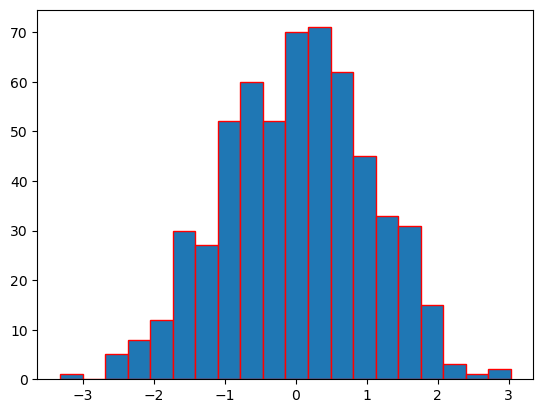

In [32]:
plt.hist(err_train,edgecolor='red',bins=20);

In [33]:
err_train.skew()

np.float64(-0.10662896981061146)

In [34]:
err_train.kurtosis()+3

np.float64(2.720630720949056)

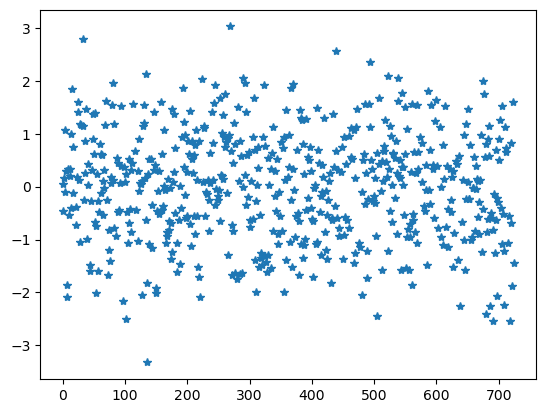

In [35]:
plt.plot(err_train,'*')

In [36]:
pred_act=pd.DataFrame()
pred_act['Actual']=lung_train_y
pred_act['Pred']=pred_train
pred_act

,Actual,Pred
73,7.825,9.498827
674,7.475,7.902508
420,9.025,7.730782
429,9.450,9.193260
158,10.350,10.791317
...,...,...
104,7.950,9.008904
76,7.500,8.903300
5,6.225,5.936400
136,7.550,9.374126


<Axes: xlabel='Actual', ylabel='Pred'>

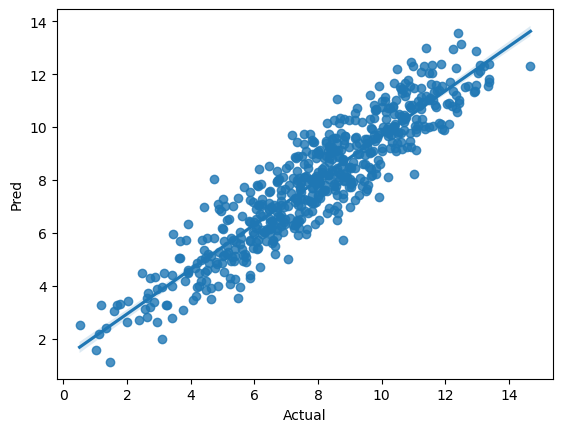

In [37]:
sns.regplot(x='Actual',y='Pred',data=pred_act)

In [38]:
err_test=lung_test_y-pred_test
err_test

165   -0.875572
191    0.398597
152    1.394600
532    0.300287
593    0.800725
         ...   
228    1.234110
42     0.370459
326   -1.371890
609    0.961227
721   -0.978417
Name: LungCap, Length: 145, dtype: float64

In [39]:
import numpy as np

In [40]:
mse=np.mean(np.square(err_test))
mse

np.float64(0.9466110689438132)

In [41]:
np.sqrt(mse)

np.float64(0.9729393963365925)

In [42]:
mape=np.mean(np.abs(err_test*100/lung_test_y))

In [43]:
mape

np.float64(13.900279508180128)

In [44]:
acc=100-mape
print(acc)

86.09972049181987
